In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = "/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv"

data = pd.read_csv(file_path , index_col = 'CustomerID')


In [4]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [5]:
data.shape

(200, 4)

In [6]:
data.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

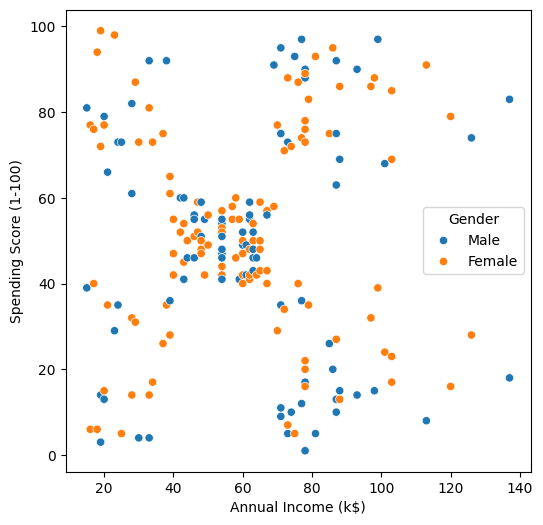

In [7]:
plt.figure(figsize = (6,6))

sns.scatterplot(x = data['Annual Income (k$)'] , y = data['Spending Score (1-100)'] , hue = data['Gender'])

Quick note:

The plot clearly shows 5 distinct groups of customers based on their Income and Spending Score, which helps us easily understand their shopping behavior

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

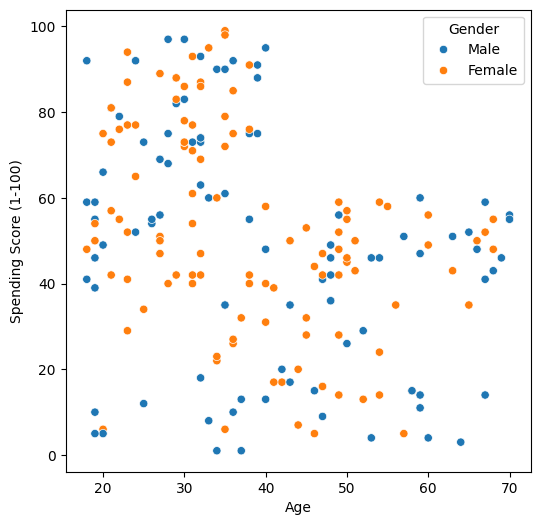

In [8]:
plt.figure(figsize = (6,6))

sns.scatterplot(x = data['Age'] , y = data['Spending Score (1-100)'] , hue = data['Gender'])

The gender feature does not provide useful information for clustering.

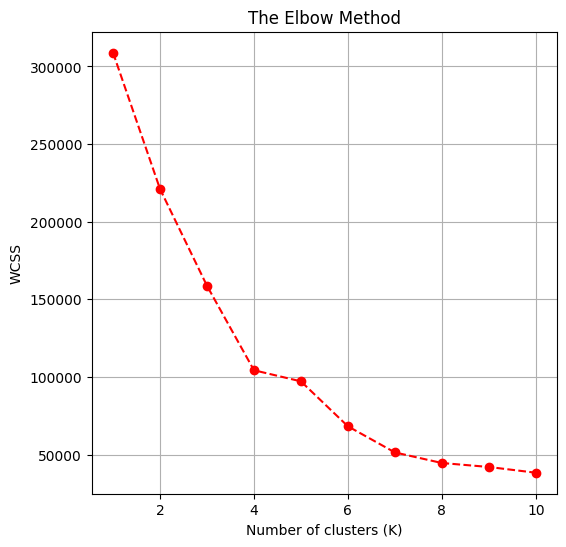

In [9]:
from sklearn.cluster import KMeans

X = data.drop('Gender' , axis = 1)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) 

plt.figure(figsize=(6, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

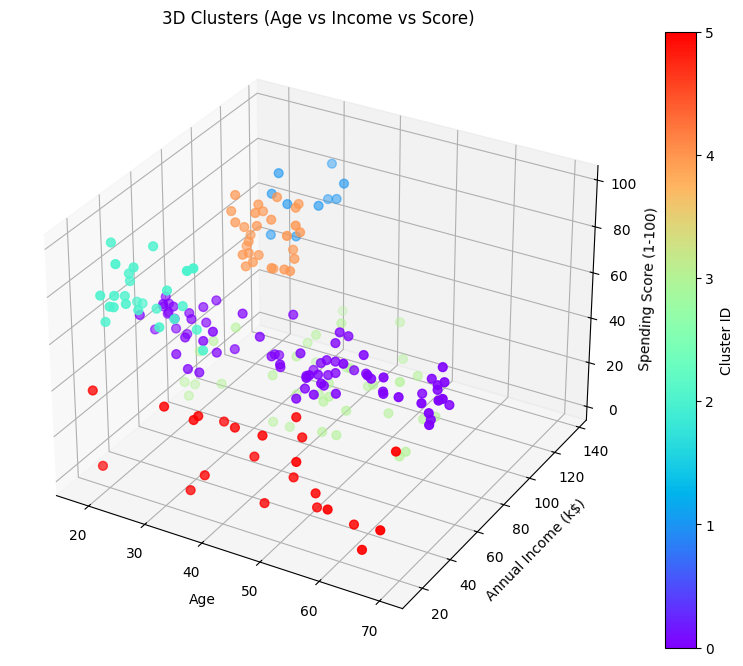

In [10]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X.values[:, 0], X.values[:, 1], X.values[:, 2], c=y_kmeans, cmap='rainbow', s=40)

ax.set_title('3D Clusters (Age vs Income vs Score)')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
fig.colorbar(scatter, ax=ax, label='Cluster ID')
plt.show()

Gender feat makes points  overlap and blend together without showing any clear patterns.

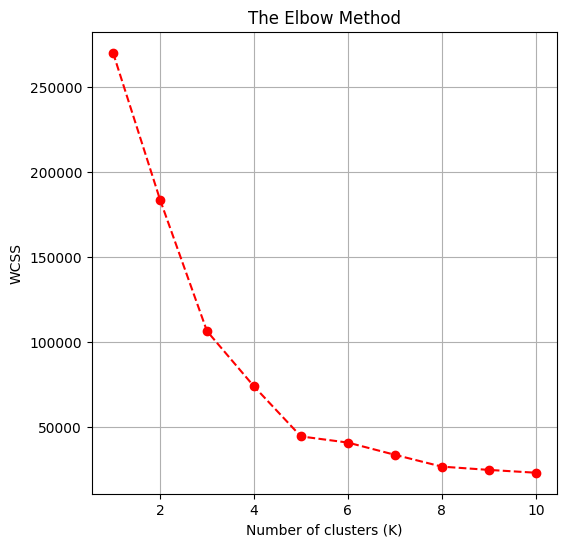

In [11]:
from sklearn.cluster import KMeans

X = data[['Annual Income (k$)' , 'Spending Score (1-100)']]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) 

plt.figure(figsize=(6, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

**5 clusters is the best choice.**

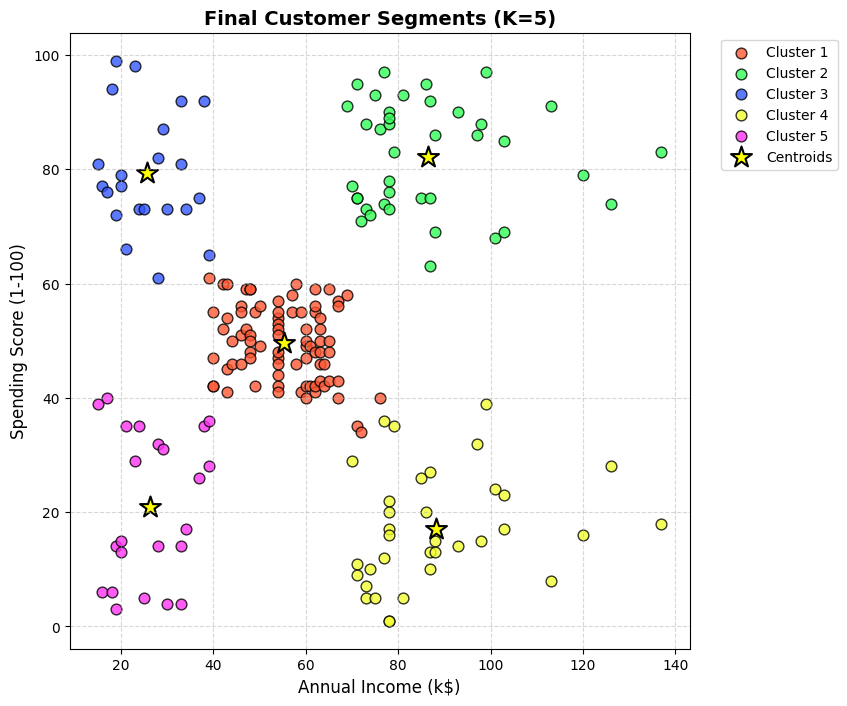

In [12]:
X_final = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_final)


plt.figure(figsize=(8, 8))


colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33', '#FF33F3']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']


for i in range(5):
    plt.scatter(X_final[y_kmeans == i, 0], 
                X_final[y_kmeans == i, 1], 
                s=60, 
                c=colors[i], 
                label=labels[i], 
                edgecolors='black', 
                alpha=0.8)


plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            s=250, 
            c='yellow', 
            marker='*', 
            label='Centroids', 
            edgecolors='black', 
            linewidths=1.5)


plt.title('Final Customer Segments (K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))     
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()